___

<a href='http://www.pieriandata.com'> <img src='../Pierian_Data_Logo.png' /></a>
___

# Finance Data Project - Solutions

In this data project we will focus on exploratory data analysis of stock prices. Keep in mind, this project is just meant to practice your visualization and pandas skills, it is not meant to be a robust financial analysis or be taken as financial advice.
____
** NOTE: This project is extremely challenging because it will introduce a lot of new concepts and have you looking things up on your own (we'll point you in the right direction) to try to solve the tasks issued. Feel free to just go through the solutions lecture notebook and video as a "walkthrough" project if you don't want to have to look things up yourself. You'll still learn a lot that way! **
____
We'll focus on bank stocks and see how they progressed throughout the [financial crisis](https://en.wikipedia.org/wiki/Financial_crisis_of_2007%E2%80%9308) all the way to early 2016.

## Get the Data

In this section we will learn how to use pandas to directly read data from Google finance using pandas!

First we need to start with the proper imports, which we've already laid out for you here.

*Note: [You'll need to install pandas-datareader for this to work!](https://github.com/pydata/pandas-datareader) Pandas datareader allows you to [read stock information directly from the internet](http://pandas.pydata.org/pandas-docs/stable/remote_data.html) Use these links for install guidance (**pip install pandas-datareader**), or just follow along with the video lecture.*

### The Imports

Already filled out for you.

In [7]:
%pip install yfinance

  Using cached pytz-2026.4-py2.py3-none-any.whl.metadata (22 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 4.0 MB/s eta 0:00:01
   --------------------- ------------------ 1.0/2.0 MB 3.9 MB/s eta 0:00:01
   ------------------------------------- -- 1.8/2.0 MB 3.3 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 3.3 MB/s  0:00:00
Using cached pytz-2026.4-py2.py3-none-any.whl (506 kB)

   ----------------------------------------  0/11 [pytz]
   ----------------------------------------  0/11 [pytz]
   --- ------------------------------------  1/11 [multitasking]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/11 [websockets]
   ------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
%pip install pandas-datareader

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pandas_datareader import data, wb
import pandas as pd
import numpy as np
import datetime
%matplotlib inline

## Data

We need to get data using pandas datareader. We will get stock information for the following banks:
*  Bank of America
* CitiGroup
* Goldman Sachs
* JPMorgan Chase
* Morgan Stanley
* Wells Fargo

** Figure out how to get the stock data from Jan 1st 2006 to Jan 1st 2016 for each of these banks. Set each bank to be a separate dataframe, with the variable name for that bank being its ticker symbol. This will involve a few steps:**
1. Use datetime to set start and end datetime objects.
2. Figure out the ticker symbol for each bank.
2. Figure out how to use datareader to grab info on the stock.

** Use [this documentation page](https://pandas-datareader.readthedocs.io/en/latest/remote_data.html) for hints and instructions (it should just be a matter of replacing certain values. Use google finance as a source, for example:**
    
    # Bank of America
    BAC = data.DataReader("BAC", 'google', start, end)

### WARNING: MAKE SURE TO CHECK THE LINK ABOVE FOR THE LATEST WORKING API. "google" MAY NOT ALWAYS WORK.

In [3]:
start = datetime.datetime(2006, 1, 1)
end = datetime.datetime(2016, 1, 1)

In [8]:
import yfinance as yf

BAC = yf.Ticker("BAC").history(start=start, end=end, auto_adjust=False)
C   = yf.Ticker("C").history(start=start, end=end, auto_adjust=False)
GS  = yf.Ticker("GS").history(start=start, end=end, auto_adjust=False)
JPM = yf.Ticker("JPM").history(start=start, end=end, auto_adjust=False)
MS  = yf.Ticker("MS").history(start=start, end=end, auto_adjust=False)
WFC = yf.Ticker("WFC").history(start=start, end=end, auto_adjust=False)

In [10]:
import yfinance as yf

df = yf.download(
    ["BAC", "C", "GS", "JPM", "MS", "WFC"],
    start=start,
    end=end,
    auto_adjust=False
)

[*********************100%***********************]  6 of 6 completed


** Create a list of the ticker symbols (as strings) in alphabetical order. Call this list: tickers**

In [11]:
tickers = ['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC']

** Use pd.concat to concatenate the bank dataframes together to a single data frame called bank_stocks. Set the keys argument equal to the tickers list. Also pay attention to what axis you concatenate on.**

In [12]:
bank_stocks = pd.concat([BAC, C, GS, JPM, MS, WFC],axis=1,keys=tickers)

** Set the column name levels (this is filled out for you):**

In [13]:
bank_stocks.columns.names = ['Bank Ticker','Stock Info']

** Check the head of the bank_stocks dataframe.**

In [14]:
bank_stocks.head()

Bank Ticker                      BAC                                   \
Stock Info                      Open       High        Low      Close   
Date                                                                    
2006-01-03 00:00:00-05:00  46.919998  47.180000  46.150002  47.080002   
2006-01-04 00:00:00-05:00  47.000000  47.240002  46.450001  46.580002   
2006-01-05 00:00:00-05:00  46.580002  46.830002  46.320000  46.639999   
2006-01-06 00:00:00-05:00  46.799999  46.910000  46.349998  46.570000   
2006-01-09 00:00:00-05:00  46.720001  46.970001  46.360001  46.599998   

Bank Ticker                                                            \
Stock Info                 Adj Close    Volume Dividends Stock Splits   
Date                                                                    
2006-01-03 00:00:00-05:00  30.176380  16296700       0.0          0.0   
2006-01-04 00:00:00-05:00  29.855894  17757900       0.0          0.0   
2006-01-05 00:00:00-05:00  29.894367  14970700       0.0          0.0   
2006-01-06 00:00:00-05:00  29.849487  12599800       0.0          0.0   
2006-01-09 00:00:00-05:00  29.868719  15619400       0.0          0.0   

Bank Ticker                         C              ...        MS               \
Stock Info                       Open        High  ... Dividends Stock Splits   
Date                                               ...                          
2006-01-03 00:00:00-05:00  490.000000  493.799988  ...       0.0          0.0   
2006-01-04 00:00:00-05:00  488.600006  491.000000  ...       0.0          0.0   
2006-01-05 00:00:00-05:00  484.399994  487.799988  ...       0.0          0.0   
2006-01-06 00:00:00-05:00  488.799988  489.000000  ...       0.0          0.0   
2006-01-09 00:00:00-05:00  486.000000  487.399994  ...       0.0          0.0   

Bank Ticker                      WFC                                   \
Stock Info                      Open       High        Low      Close   
Date                                                                    
2006-01-03 00:00:00-05:00  31.600000  31.975000  31.195000  31.900000   
2006-01-04 00:00:00-05:00  31.799999  31.820000  31.365000  31.530001   
2006-01-05 00:00:00-05:00  31.500000  31.555000  31.309999  31.495001   
2006-01-06 00:00:00-05:00  31.580000  31.775000  31.385000  31.680000   
2006-01-09 00:00:00-05:00  31.674999  31.825001  31.555000  31.674999   

Bank Ticker                                                            
Stock Info                 Adj Close    Volume Dividends Stock Splits  
Date                                                                   
2006-01-03 00:00:00-05:00  18.170341  11016400       0.0          0.0  
2006-01-04 00:00:00-05:00  17.959591  10870000       0.0          0.0  
2006-01-05 00:00:00-05:00  17.939659  10158000       0.0          0.0  
2006-01-06 00:00:00-05:00  18.045029   8403800       0.0          0.0  
2006-01-09 00:00:00-05:00  18.042179   5619600       0.0          0.0  

[5 rows x 48 columns]

# EDA

Let's explore the data a bit! Before continuing, I encourage you to check out the documentation on [Multi-Level Indexing](http://pandas.pydata.org/pandas-docs/stable/advanced.html) and [Using .xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html).
Reference the solutions if you can not figure out how to use .xs(), since that will be a major part of this project.

** What is the max Close price for each bank's stock throughout the time period?**

In [15]:
bank_stocks.xs(key='Close',axis=1,level='Stock Info').max()

Bank Ticker
BAC     54.900002
C      564.099976
GS     247.919998
JPM     70.080002
MS      89.300003
WFC     58.520000
dtype: float64

** Create a new empty DataFrame called returns. This dataframe will contain the returns for each bank's stock. returns are typically defined by:**

$$r_t = \frac{p_t - p_{t-1}}{p_{t-1}} = \frac{p_t}{p_{t-1}} - 1$$

In [16]:
returns = pd.DataFrame()

** We can use pandas pct_change() method on the Close column to create a column representing this return value. Create a for loop that goes and for each Bank Stock Ticker creates this returns column and set's it as a column in the returns DataFrame.**

In [17]:
for tick in tickers:
    returns[tick+' Return'] = bank_stocks[tick]['Close'].pct_change()
returns.head()

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03 00:00:00-05:00,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04 00:00:00-05:00,-0.010620,-0.018462,-0.013812,-0.014183,0.000686,-0.011599
2006-01-05 00:00:00-05:00,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.001110
2006-01-06 00:00:00-05:00,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005874
2006-01-09 00:00:00-05:00,0.000644,-0.004731,0.012030,0.016242,0.010586,-0.000158


** Create a pairplot using seaborn of the returns dataframe. What stock stands out to you? Can you figure out why?**

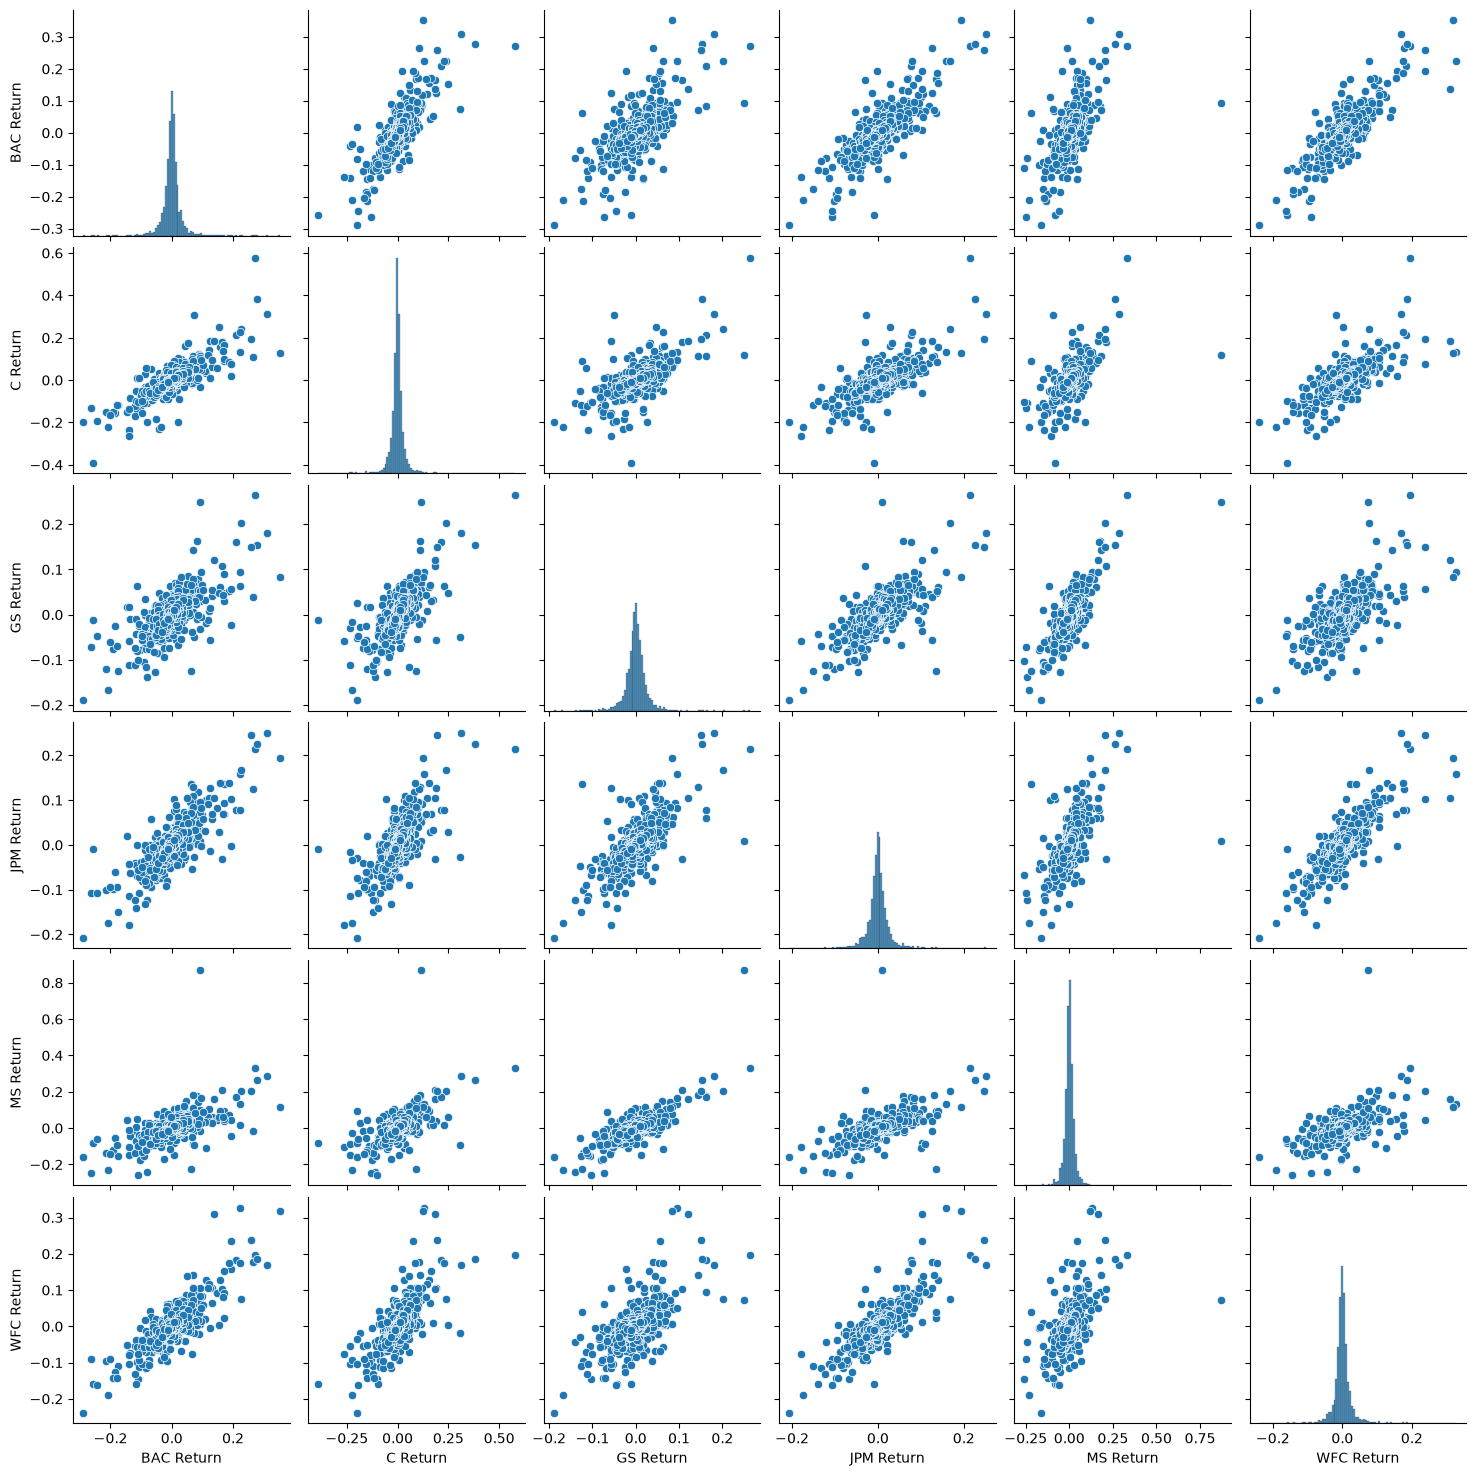

In [18]:
import seaborn as sns
sns.pairplot(returns[1:])

Background on [Citigroup's Stock Crash available here.](https://en.wikipedia.org/wiki/Citigroup#November_2008.2C_Collapse_.26_US_Government_Intervention_.28part_of_the_Global_Financial_Crisis.29) 

You'll also see the enormous crash in value if you take a look a the stock price plot (which we do later in the visualizations.)

** Using this returns DataFrame, figure out on what dates each bank stock had the best and worst single day returns. You should notice that 4 of the banks share the same day for the worst drop, did anything significant happen that day?**

In [19]:
returns.idxmin()

BAC Return   2009-01-20 00:00:00-05:00
C Return     2009-02-27 00:00:00-05:00
GS Return    2009-01-20 00:00:00-05:00
JPM Return   2009-01-20 00:00:00-05:00
MS Return    2008-10-09 00:00:00-04:00
WFC Return   2009-01-20 00:00:00-05:00
dtype: datetime64[s, America/New_York]

** You should have noticed that Citigroup's largest drop and biggest gain were very close to one another, did anythign significant happen in that time frame? **

[Citigroup had a stock split.](https://www.google.com/webhp?sourceid=chrome-instant&ion=1&espv=2&ie=UTF-8#q=citigroup+stock+2011+may)

In [ ]:
returns.idxmax()

BAC Return   2009-04-09 00:00:00-04:00
C Return     2008-11-24 00:00:00-05:00
GS Return    2008-11-24 00:00:00-05:00
JPM Return   2009-01-21 00:00:00-05:00
MS Return    2008-10-13 00:00:00-04:00
WFC Return   2008-07-16 00:00:00-04:00
dtype: datetime64[s, America/New_York]

** Take a look at the standard deviation of the returns, which stock would you classify as the riskiest over the entire time period? Which would you classify as the riskiest for the year 2015?**

In [21]:
returns.std() 

BAC Return    0.036647
C Return      0.038672
GS Return     0.025390
JPM Return    0.027667
MS Return     0.037819
WFC Return    0.030238
dtype: float64

In [23]:
returns.loc["2015-01-01":"2015-12-31"].std()

BAC Return    0.016163
C Return      0.015289
GS Return     0.014046
JPM Return    0.014017
MS Return     0.016249
WFC Return    0.012591
dtype: float64

** Create a distplot using seaborn of the 2015 returns for Morgan Stanley **

C:\Users\Rushil Jivan\AppData\Local\Temp\ipykernel_21296\1960598734.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(returns.loc['2015-01-01':'2015-12-31']['MS Return'],color='green',bins=100)


<Axes: xlabel='MS Return', ylabel='Density'>

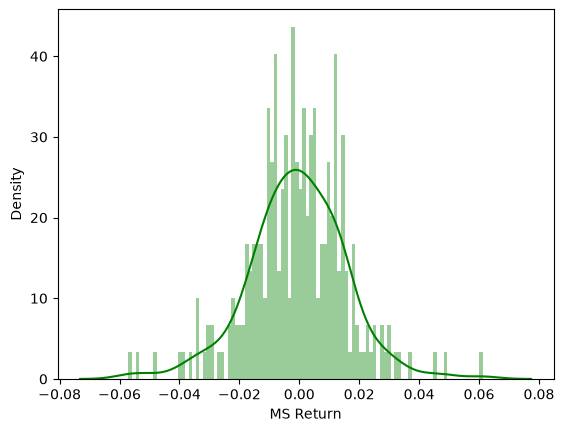

In [25]:
sns.distplot(returns.loc['2015-01-01':'2015-12-31']['MS Return'],color='green',bins=100)

** Create a distplot using seaborn of the 2008 returns for CitiGroup **

C:\Users\Rushil Jivan\AppData\Local\Temp\ipykernel_21296\1612079653.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(returns.loc['2008-01-01':'2008-12-31']['C Return'],color='red',bins=100)


<Axes: xlabel='C Return', ylabel='Density'>

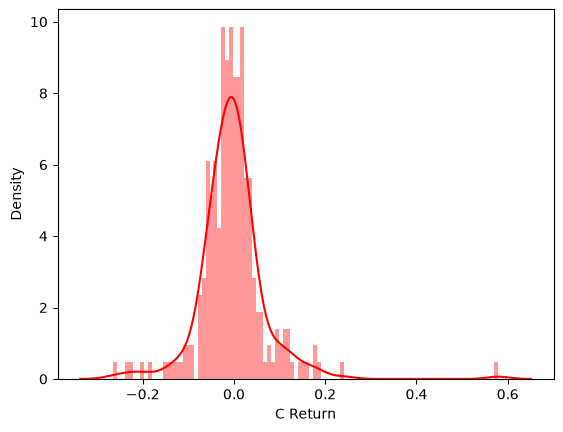

In [27]:
sns.distplot(returns.loc['2008-01-01':'2008-12-31']['C Return'],color='red',bins=100)

____
# More Visualization

A lot of this project will focus on visualizations. Feel free to use any of your preferred visualization libraries to try to recreate the described plots below, seaborn, matplotlib, plotly and cufflinks, or just pandas.

### Imports

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline


import plotly
import cufflinks as cf
cf.go_offline()

** Create a line plot showing Close price for each bank for the entire index of time. (Hint: Try using a for loop, or use [.xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html) to get a cross section of the data.)**

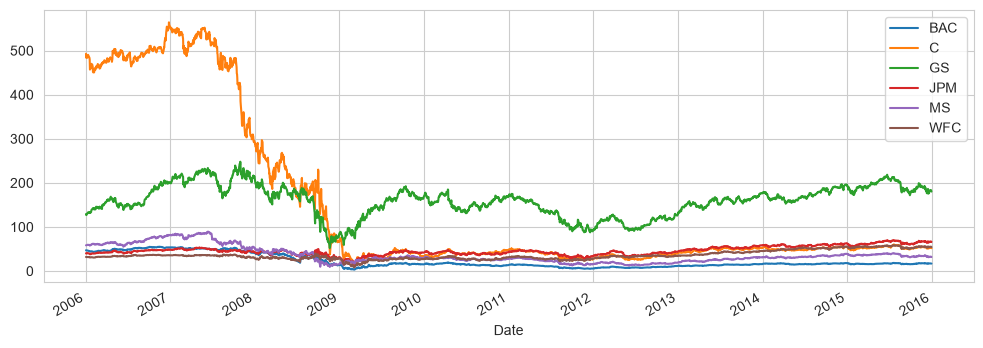

In [30]:
for tick in tickers:
    bank_stocks[tick]['Close'].plot(figsize=(12,4),label=tick)
plt.legend()

<Axes: xlabel='Date'>

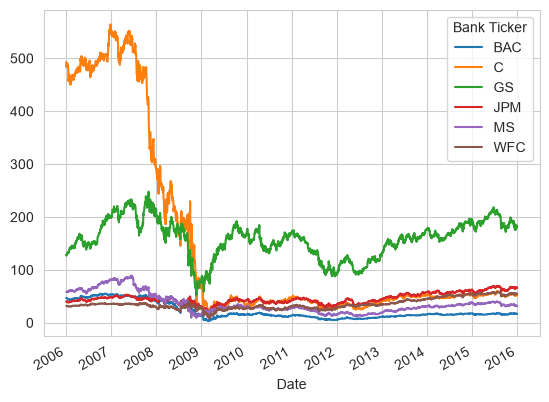

In [31]:
bank_stocks.xs(key='Close',axis=1,level='Stock Info').plot()

<Axes: title={'center': 'Bank stocks — closing prices'}, xlabel='Date'>

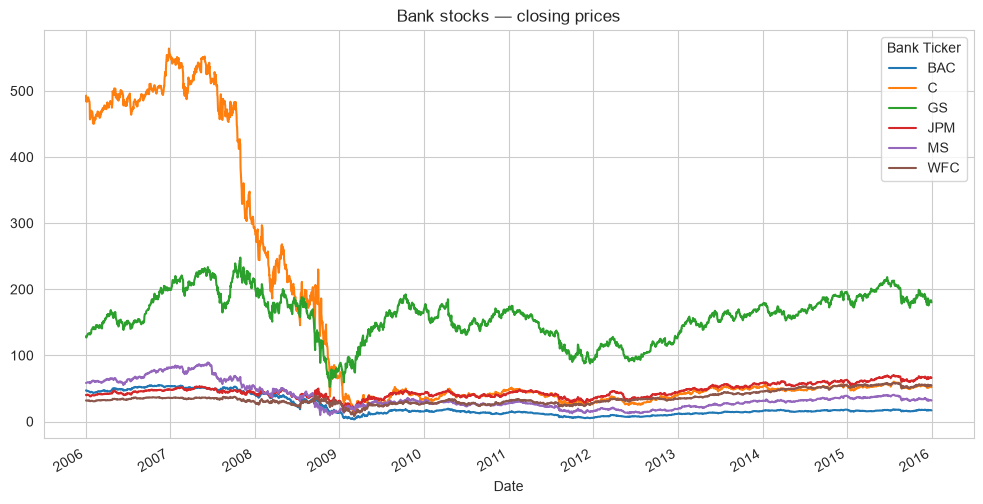

In [36]:
close = bank_stocks.xs("Close", axis=1, level="Stock Info")
close.plot(figsize=(12, 6), title="Bank stocks — closing prices")

## Moving Averages

Let's analyze the moving averages for these stocks in the year 2008. 

** Plot the rolling 30 day average against the Close Price for Bank Of America's stock for the year 2008**

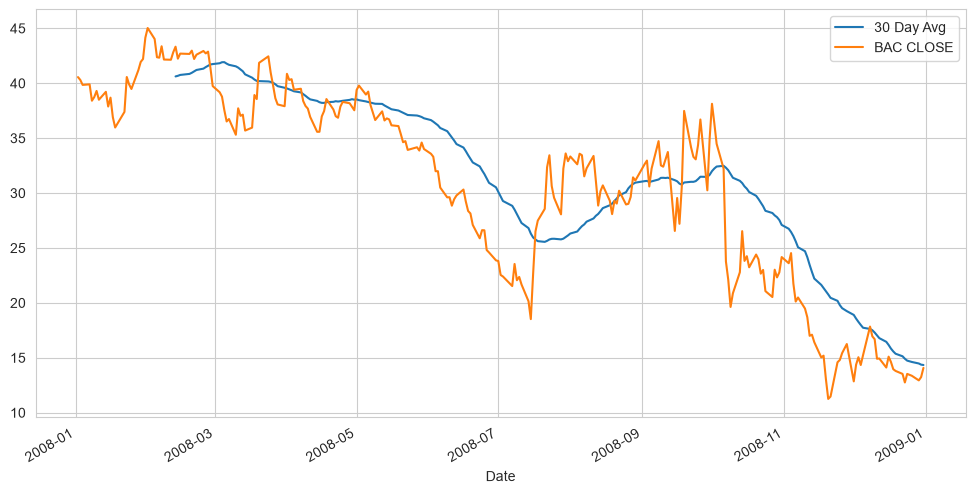

In [37]:
plt.figure(figsize=(12,6))
BAC['Close'].loc['2008-01-01':'2009-01-01'].rolling(window=30).mean().plot(label='30 Day Avg')
BAC['Close'].loc['2008-01-01':'2009-01-01'].plot(label='BAC CLOSE')
plt.legend()

** Create a heatmap of the correlation between the stocks Close Price.**

<Axes: xlabel='Bank Ticker', ylabel='Bank Ticker'>

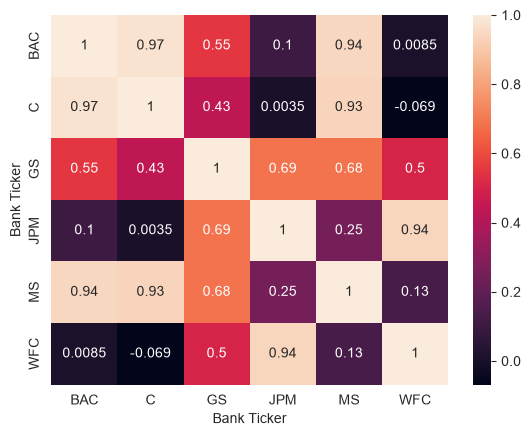

In [38]:
sns.heatmap(bank_stocks.xs(key='Close',axis=1,level='Stock Info').corr(),annot=True)

** Optional: Use seaborn's clustermap to cluster the correlations together:**

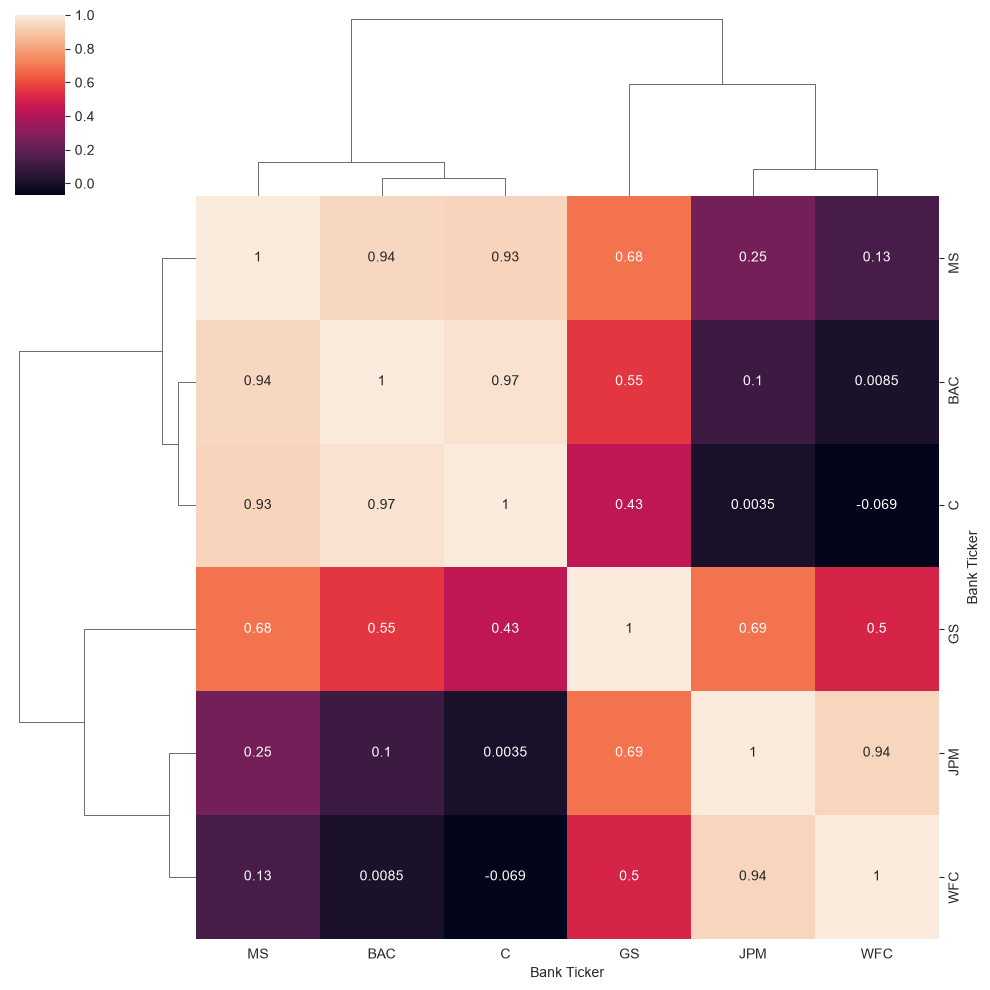

In [39]:
sns.clustermap(bank_stocks.xs(key='Close',axis=1,level='Stock Info').corr(),annot=True)

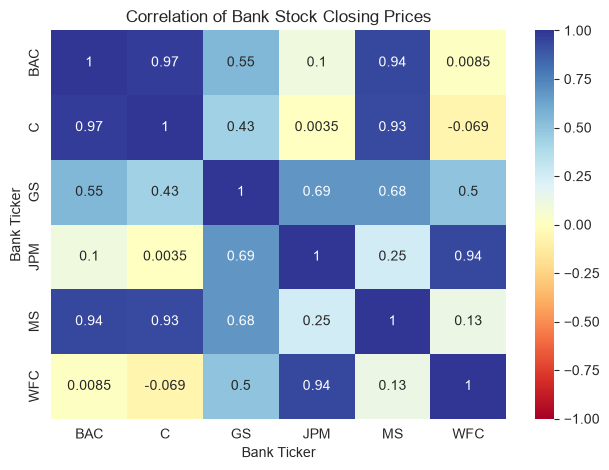

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

close = bank_stocks.xs("Close", axis=1, level="Stock Info")
close_corr = close.corr()

sns.heatmap(close_corr, annot=True, cmap="RdYlBu", vmin=-1, vmax=1)
plt.title("Correlation of Bank Stock Closing Prices")
plt.tight_layout()
plt.show()

# Part 2 (Optional)

In this second part of the project we will rely on the cufflinks library to create some Technical Analysis plots. This part of the project is experimental due to its heavy reliance on the cuffinks project, so feel free to skip it if any functionality is broken in the future.

** Use .iplot(kind='candle) to create a candle plot of Bank of America's stock from Jan 1st 2015 to Jan 1st 2016.**

In [47]:
import plotly.graph_objects as go

ohlc = BAC.loc["2015-01-01":"2016-01-01", ["Open", "High", "Low", "Close"]]

fig = go.Figure(data=[go.Candlestick(
    x=ohlc.index,
    open=ohlc["Open"],
    high=ohlc["High"],
    low=ohlc["Low"],
    close=ohlc["Close"],
)])

fig.update_layout(title="BAC Candlestick Chart", xaxis_title="Date", yaxis_title="Price")
fig.show()

** Use .ta_plot(study='sma') to create a Simple Moving Averages plot of Morgan Stanley for the year 2015.**

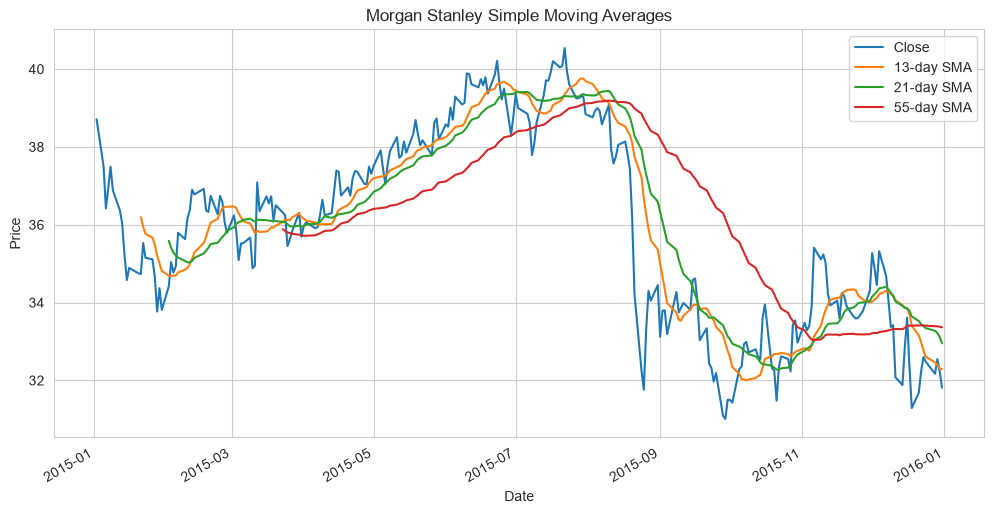

In [48]:
import matplotlib.pyplot as plt

close = MS["Close"].loc["2015-01-01":"2016-01-01"]

ax = close.plot(figsize=(12, 6), label="Close")
for period in [13, 21, 55]:
    close.rolling(window=period).mean().plot(ax=ax, label=f"{period}-day SMA")

ax.set_title("Morgan Stanley Simple Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.show()

**Use .ta_plot(study='boll') to create a Bollinger Band Plot for Bank of America for the year 2015.**

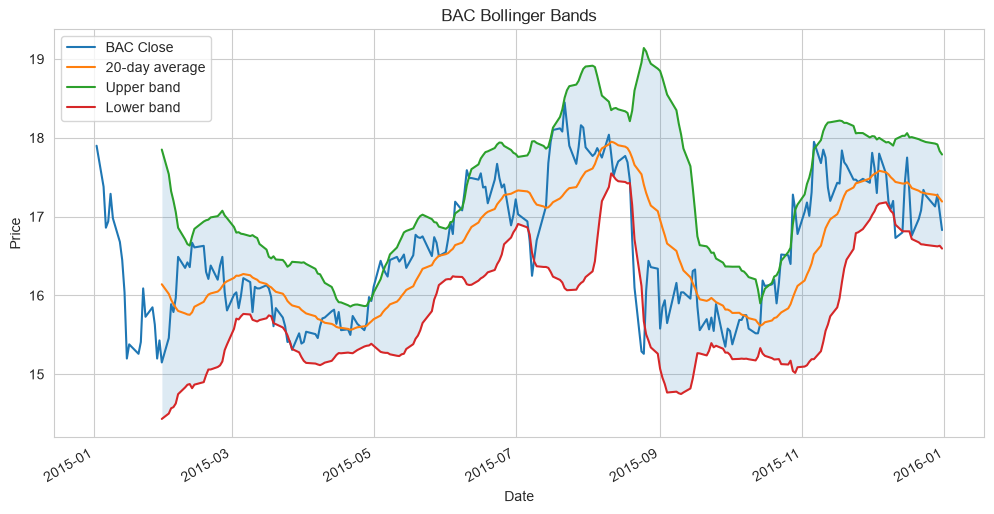

In [50]:
import matplotlib.pyplot as plt

close = BAC["Close"].loc["2015-01-01":"2016-01-01"]

middle = close.rolling(window=20).mean()
std = close.rolling(window=20).std()
upper = middle + 2 * std
lower = middle - 2 * std

ax = close.plot(figsize=(12, 6), label="BAC Close")
middle.plot(ax=ax, label="20-day average")
upper.plot(ax=ax, label="Upper band")
lower.plot(ax=ax, label="Lower band")

ax.fill_between(close.index, lower, upper, alpha=0.15)
ax.set_title("BAC Bollinger Bands")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.show()

# Great Job!

Definitely a lot of more specific finance topics here, so don't worry if you didn't understand them all! The only thing you should be concerned with understanding are the basic pandas and visualization oeprations.